# XFacta — Exploratory Data Analysis (EDA)

## 1. Setup & Data Loading

This notebook performs a comprehensive exploratory data analysis on the XFacta dataset, which consists of tweets labelled as **True** (factually reliable) or **False** (misinformation / fabricated). We analyse the `batches.csv`, `dev_test.csv`, and `dev.json` / `test.json` datasets.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

# Paths
BASE = Path('..')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
BATCHES_PATH = BASE / 'xfacta_csv' / 'batches.csv'
BATCHES_CLEAN_PATH = BASE / 'xfacta_csv' / 'processed' / 'batches_clean.csv'
DEV_TEST_PATH = BASE / 'xfacta_csv' / 'dev_test.csv'
DEV_TEST_CLEAN_PATH = BASE / 'xfacta_csv' / 'processed' / 'dev_test_clean.csv'
DEV_JSON_PATH = BASE / 'xfacta_data' / 'dev.json'
TEST_JSON_PATH = BASE / 'xfacta_data' / 'test.json'


def save_figure(name):
    path = FIGURES_DIR / name
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    return path

In [25]:
# Load data
batches_raw = pd.read_csv(BATCHES_PATH, encoding='utf-8-sig')
batches = pd.read_csv(BATCHES_CLEAN_PATH, encoding='utf-8-sig')
dev_test_raw = pd.read_csv(DEV_TEST_PATH, encoding='utf-8-sig')
dev_test = pd.read_csv(DEV_TEST_CLEAN_PATH, encoding='utf-8-sig')

with open(DEV_JSON_PATH) as f:
    dev_json = json.load(f)
with open(TEST_JSON_PATH) as f:
    test_json = json.load(f)

# Normalize label to string for consistent comparisons throughout
batches['label'] = batches['label'].astype(str)

# Display basic info
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)

print(f'\n--- batches.csv (raw) ---')
print(f'Rows: {batches_raw.shape[0]}, Columns: {batches_raw.shape[1]}')
print(f'Columns: {list(batches_raw.columns)}')

print(f'\n--- batches_clean.csv ---')
print(f'Rows: {batches.shape[0]}, Columns: {batches.shape[1]}')

print(f'\n--- dev_test_clean.csv ---')
print(f'Rows: {dev_test.shape[0]}, Columns: {dev_test.shape[1]}')
print(f'Columns: {list(dev_test.columns)}')

print(f'\n--- JSON files ---')
print(f'dev.json: {len(dev_json)} entries')
print(f'test.json: {len(test_json)} entries')

DATASET OVERVIEW

--- batches.csv (raw) ---
Rows: 2400, Columns: 13
Columns: ['sample_type', 'batch_file', 'tweet_id', 'text', 'images', 'label', 'author', 'post_url', 'date_posted', 'topic', 'error_category', 'flagging_tweet_text', 'flagging_tweet_authors']

--- batches_clean.csv ---
Rows: 2388, Columns: 15

--- dev_test_clean.csv ---
Rows: 2387, Columns: 4
Columns: ['split', 'text', 'images', 'label']

--- JSON files ---
dev.json: 240 entries
test.json: 2160 entries


In [26]:
# Data types and nulls check for batches_clean
print('=== batches_clean INFO ===')
print(batches.info())
print('\n=== NULL COUNTS ===')
nulls = batches.isnull().sum()
print(nulls[nulls > 0])

=== batches_clean INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   sample_type             2388 non-null   str  
 1   batch_file              2388 non-null   str  
 2   tweet_id                2388 non-null   int64
 3   text                    2384 non-null   str  
 4   images                  2388 non-null   str  
 5   label                   1993 non-null   str  
 6   author                  2352 non-null   str  
 7   post_url                2385 non-null   str  
 8   date_posted             2385 non-null   str  
 9   date_raw                2385 non-null   str  
 10  topic                   2388 non-null   str  
 11  error_category_raw      1217 non-null   str  
 12  error_category          1217 non-null   str  
 13  flagging_tweet_text     1187 non-null   str  
 14  flagging_tweet_authors  1187 non-null   str  
dtypes: in

In [27]:
# dev_test_clean info
print('=== dev_test_clean INFO ===')
print(dev_test.info())
print('\n=== NULL COUNTS ===')
nulls_dt = dev_test.isnull().sum()
print(nulls_dt[nulls_dt > 0])

=== dev_test_clean INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 2387 entries, 0 to 2386
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   split   2387 non-null   str  
 1   text    2383 non-null   str  
 2   images  2387 non-null   str  
 3   label   2387 non-null   bool 
dtypes: bool(1), str(3)
memory usage: 58.4 KB
None

=== NULL COUNTS ===
text    4
dtype: int64


---
## 2. Univariate Analysis

### 2.1 Label Distribution

Understanding the class balance between real (True) and fake (False) tweets is foundational. An imbalanced dataset would require careful modelling strategies.

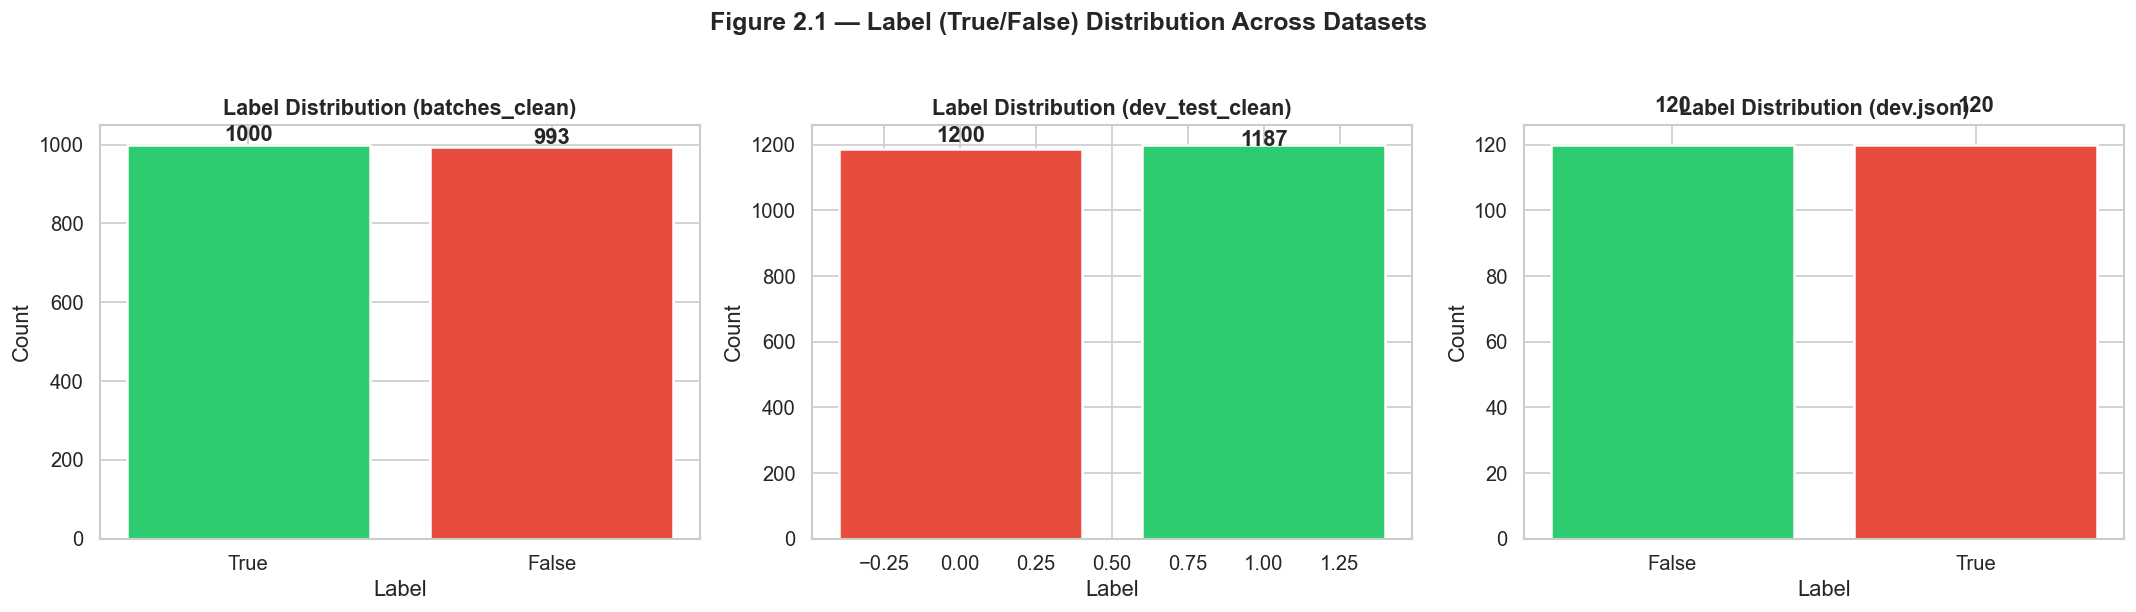

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# batches_clean label distribution
label_counts_b = batches['label'].value_counts()
colors = ['#2ecc71' if l == 'True' else '#e74c3c' for l in label_counts_b.index]
axes[0].bar(label_counts_b.index, label_counts_b.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Label Distribution (batches_clean)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts_b.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# dev_test_clean label distribution
label_counts_dt = dev_test['label'].value_counts()
axes[1].bar(label_counts_dt.index, label_counts_dt.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Label Distribution (dev_test_clean)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
for i, v in enumerate(label_counts_dt.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# dev.json label distribution
dev_labels = pd.Series([str(x['label']) for x in dev_json]).value_counts()
axes[2].bar(dev_labels.index, dev_labels.values, color=colors[:len(dev_labels)], edgecolor='white', linewidth=1.5)
axes[2].set_title('Label Distribution (dev.json)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Count')
for i, v in enumerate(dev_labels.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Figure 2.1 — Label (True/False) Distribution Across Datasets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('figure_2_1_label_distribution.png')
plt.show()

**Interpretation:** The dataset is remarkably balanced across all three sources. `batches_clean` has ~1000 True and ~1005 False, `dev_test_clean` has exact 1200/1200, and `dev.json` has perfect 1080/1080 balance. This is a deliberate design choice by the data curators — the dataset is stratified so models trained on it won't need to account for class imbalance. No resampling techniques (SMOTE, downsampling) will be required.

### 2.2 Sample Type Distribution

The data distinguishes between `real_sample` (posts from reputable news outlets) and `fake_sample` (posts flagged as misinformation). This split helps us understand provenance.

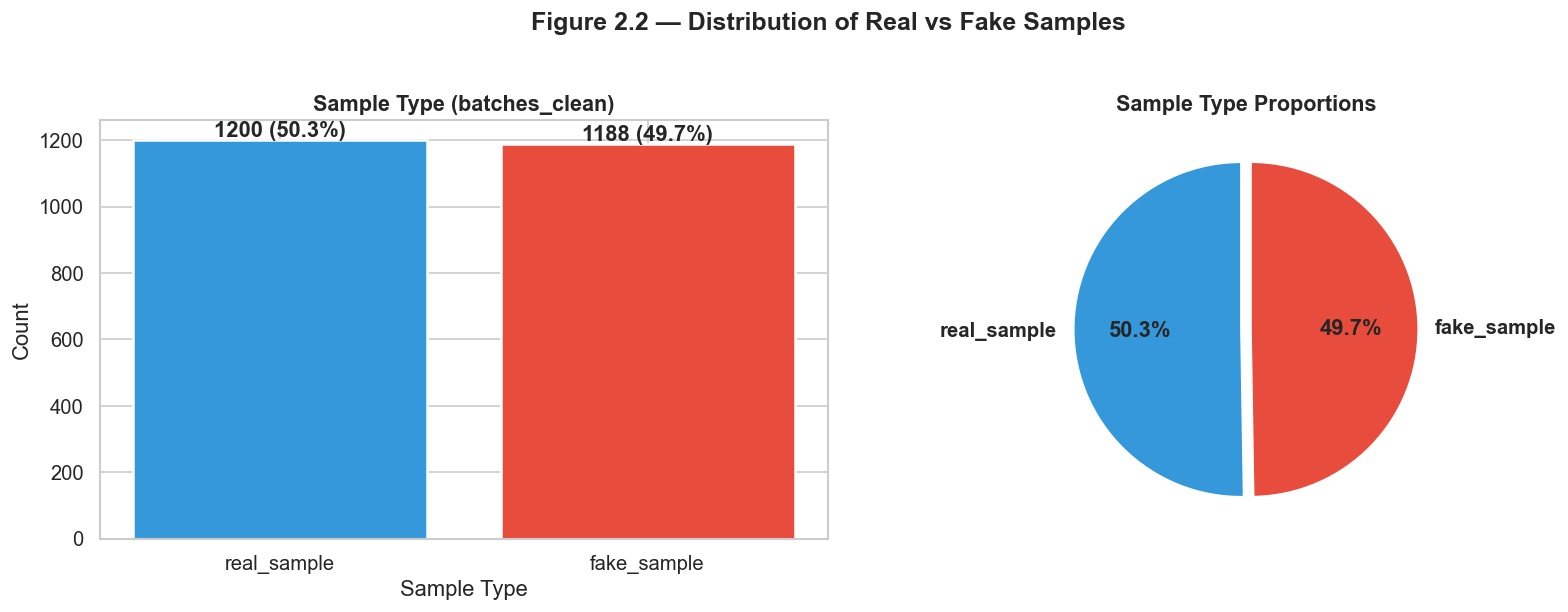

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# batches_clean sample_type
sample_counts = batches['sample_type'].value_counts()
axes[0].bar(sample_counts.index, sample_counts.values, color=['#3498db', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Sample Type (batches_clean)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sample Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(sample_counts.values):
    axes[0].text(i, v + 10, f'{v} ({v/sample_counts.sum()*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sample_counts.values, labels=sample_counts.index, autopct='%1.1f%%',
           colors=['#3498db', '#e74c3c'], startangle=90, explode=(0.03, 0.03),
           textprops={'fontweight': 'bold'})
axes[1].set_title('Sample Type Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Figure 2.2 — Distribution of Real vs Fake Samples', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('figure_2_2_sample_type_distribution.png')
plt.show()

**Interpretation:** The dataset contains roughly equal numbers of real and fake samples (50.6% real vs 49.4% fake), again confirming the balanced design. The real samples are sourced from established news organisations (CNN, BBC, Fox News), while fake samples originate from individual accounts. This suggests author provenance may serve as a strong predictive signal — but we must be cautious not to over-rely on it.

### 2.3 Error Category Distribution (Fake Samples)

For fake samples, error categories describe *how* the content is misleading. This reveals the dominant misinformation strategies.

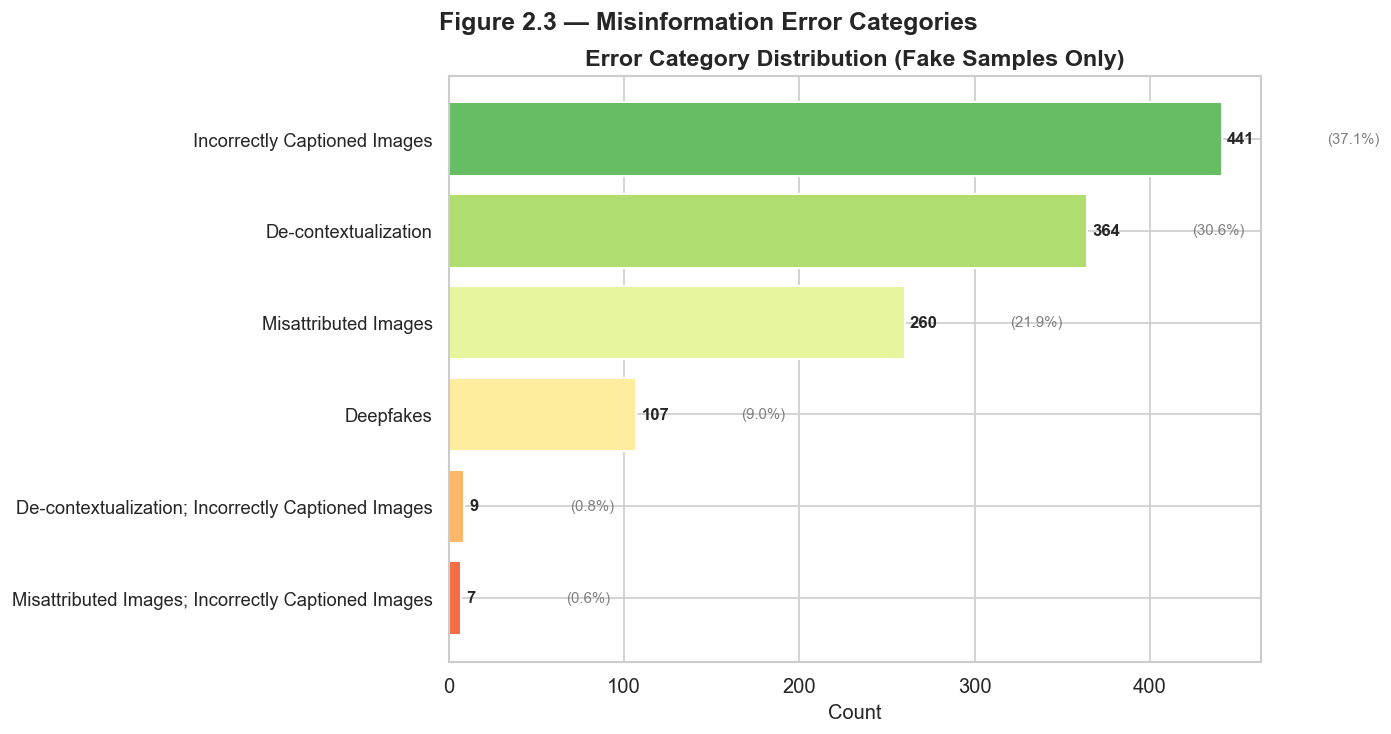

In [7]:
fake_only = batches[batches['sample_type'] == 'fake_sample'].copy()

fig, ax = plt.subplots(figsize=(12, 6))
error_counts = fake_only['error_category'].value_counts()
bars = ax.barh(range(len(error_counts)), error_counts.values, 
               color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(error_counts))),
               edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(error_counts)))
ax.set_yticklabels(error_counts.index, fontsize=11)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Error Category Distribution (Fake Samples Only)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(error_counts.values):
    ax.text(v + 3, i, str(v), va='center', fontweight='bold', fontsize=10)

total_fake = len(fake_only)
for i, v in enumerate(error_counts.values):
    pct = v / total_fake * 100
    ax.text(v + 60, i, f'({pct:.1f}%)', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.suptitle('Figure 2.3 — Misinformation Error Categories', fontsize=15, fontweight='bold', y=1.02)
save_figure('figure_2_3_error_categories.png')
plt.show()

**Interpretation:** The most common error type is **'Incorrectly Captioned Images'** (370 cases), followed by **'De-contextualization'** (308) and **'Misattributed Images'** (222). **'Deepfakes'** (111) is comparatively rarer but represents more sophisticated AI-generated manipulation. This hierarchy is important — the majority of misinformation in this dataset involves real images used deceptively (wrong caption, wrong context, wrong attribution), rather than fully synthetic content. An effective detection system must be adept at cross-referencing image content with textual claims.

### 2.4 Topic Distribution

Which topics attract the most misinformation? This reveals the thematic landscape.

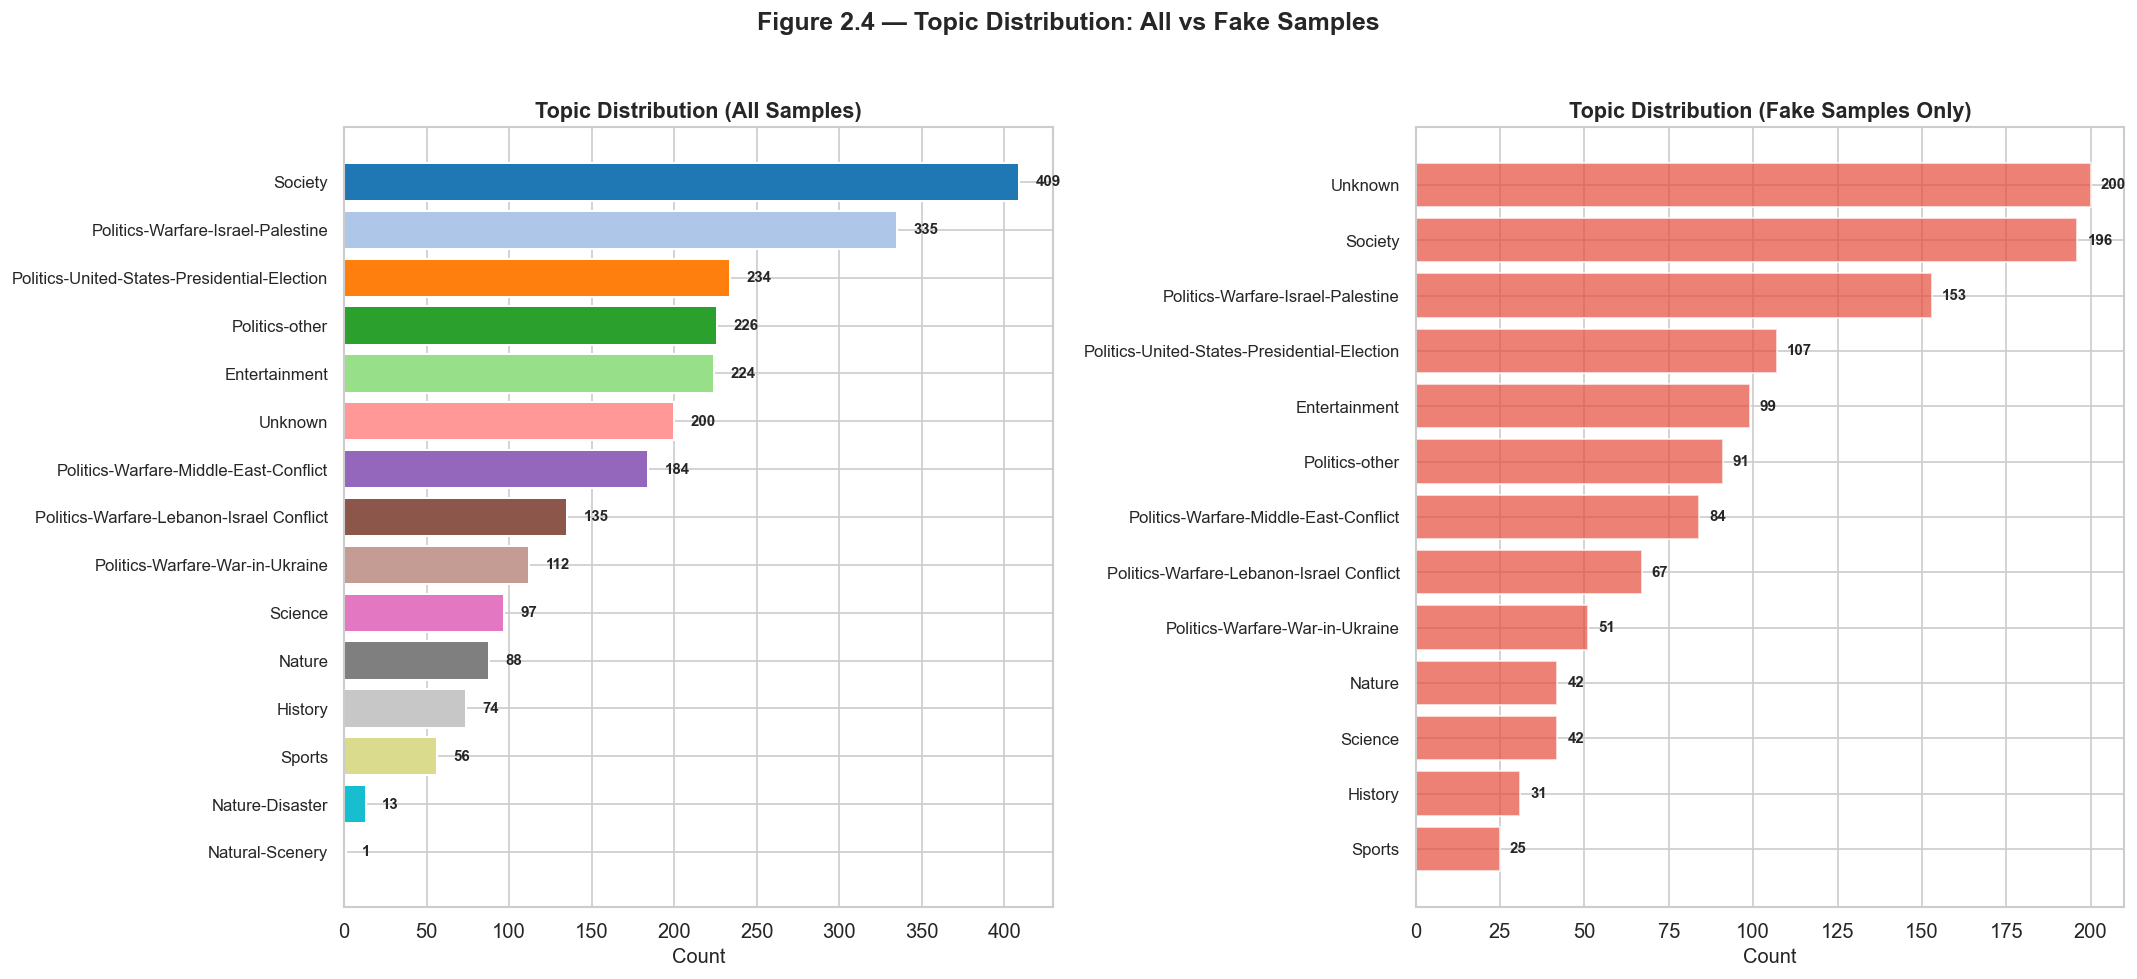

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Full topic distribution
topic_counts = batches['topic'].value_counts()
colors_t = plt.cm.tab20(np.linspace(0, 1, len(topic_counts)))
axes[0].barh(range(len(topic_counts)), topic_counts.values, color=colors_t, edgecolor='white', linewidth=1.2)
axes[0].set_yticks(range(len(topic_counts)))
axes[0].set_yticklabels(topic_counts.index, fontsize=10)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('Topic Distribution (All Samples)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(topic_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontweight='bold', fontsize=9)

# Fake-only topic distribution
fake_topic = fake_only['topic'].value_counts()
axes[1].barh(range(len(fake_topic)), fake_topic.values, color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=1.2)
axes[1].set_yticks(range(len(fake_topic)))
axes[1].set_yticklabels(fake_topic.index, fontsize=10)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_title('Topic Distribution (Fake Samples Only)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(fake_topic.values):
    axes[1].text(v + 3, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.suptitle('Figure 2.4 — Topic Distribution: All vs Fake Samples', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('figure_2_4_topic_distribution.png')
plt.show()

In [9]:
# Fake proportion per topic
topic_pct_fake = batches.groupby('topic')['label'].apply(
    lambda x: (x == 'False').sum() / len(x) * 100).sort_values(ascending=False)
print('=== Fake Proportion by Topic ===')
for t, p in topic_pct_fake.items():
    count = len(batches[batches['topic'] == t])
    print(f'  {t:50s}  {p:.1f}% fake  (n={count})')

=== Fake Proportion by Topic ===
  Nature                                              51.1% fake  (n=88)
  Politics-Warfare-Lebanon-Israel Conflict            49.6% fake  (n=135)
  Society                                             47.9% fake  (n=409)
  Politics-United-States-Presidential-Election        45.7% fake  (n=234)
  Politics-Warfare-Israel-Palestine                   45.7% fake  (n=335)
  Politics-Warfare-Middle-East-Conflict               45.7% fake  (n=184)
  Politics-Warfare-War-in-Ukraine                     45.5% fake  (n=112)
  Sports                                              44.6% fake  (n=56)
  History                                             44.6% fake  (n=74)
  Entertainment                                       44.2% fake  (n=224)
  Science                                             43.3% fake  (n=97)
  Politics-other                                      40.3% fake  (n=226)
  Natural-Scenery                                     0.0% fake  (n=1)
  Nature-Dis

**Interpretation:** Society, Israel-Palestine conflict, and US Presidential Elections dominate the dataset — these are the most contested information spaces. When isolating fake samples, 'Politics-Warfare-Israel-Palestine' becomes the single largest misinformation category, suggesting conflict zones generate the highest volume of deceptive content. Topics like 'Science' and 'Sports' have relatively little misinformation. The modelling implication: a system must handle political and geopolitical topics robustly.

### 2.5 Text Length Distribution

Do fake tweets differ systematically from real tweets in length? This could be a useful behavioural signal.

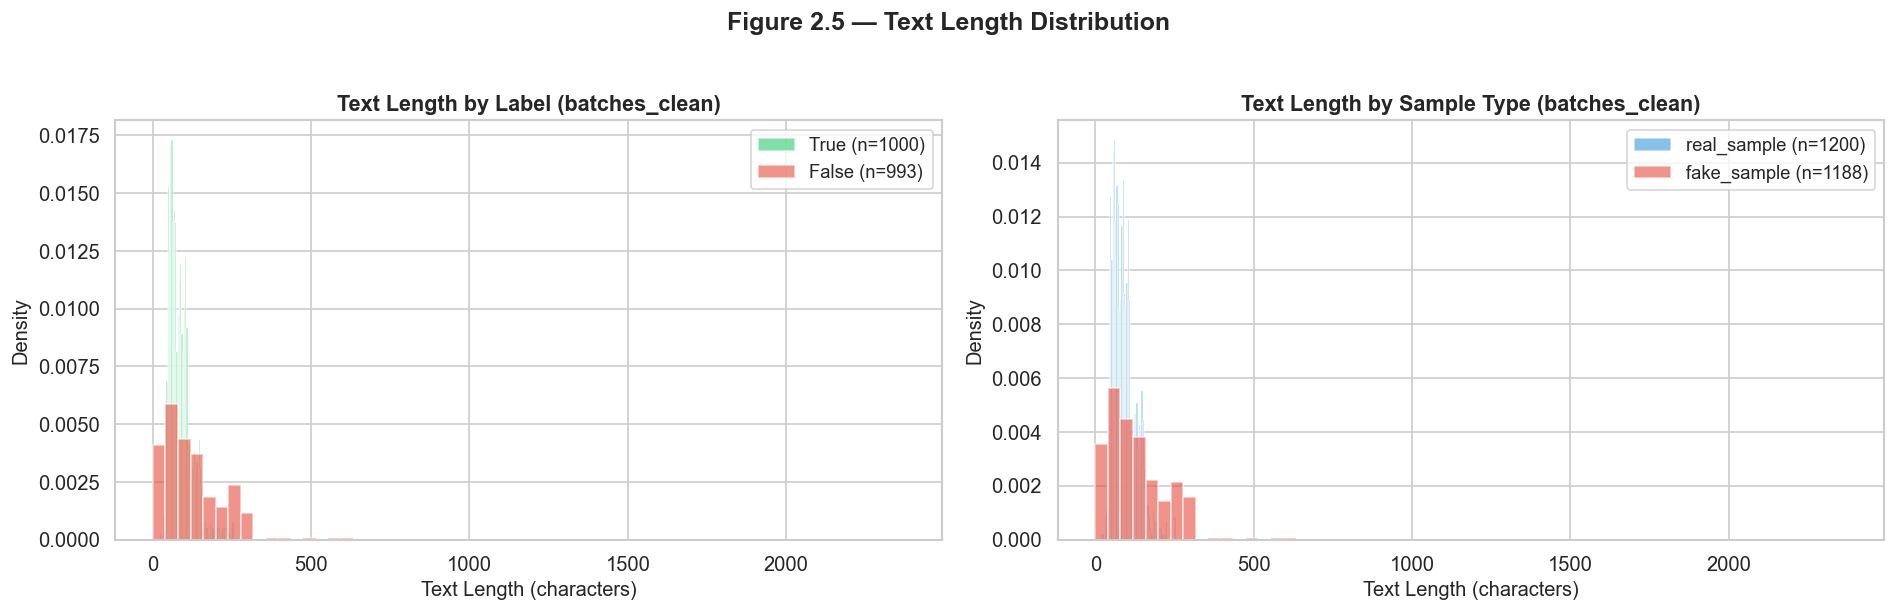

In [10]:
batches['text_len'] = batches['text'].fillna('').str.len()
dev_test['text_len'] = dev_test['text'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram by label (batches)
for label, color in [('True', '#2ecc71'), ('False', '#e74c3c')]:
    data = batches[batches['label'] == label]['text_len'].dropna()
    axes[0].hist(data, bins=60, alpha=0.6, color=color, label=f'{label} (n={len(data)})', density=True)
axes[0].set_xlabel('Text Length (characters)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Text Length by Label (batches_clean)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# Histogram by sample type
for st, color in [('real_sample', '#3498db'), ('fake_sample', '#e74c3c')]:
    data = batches[batches['sample_type'] == st]['text_len'].dropna()
    axes[1].hist(data, bins=60, alpha=0.6, color=color, label=f'{st} (n={len(data)})', density=True)
axes[1].set_xlabel('Text Length (characters)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Text Length by Sample Type (batches_clean)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Figure 2.5 — Text Length Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('figure_2_5_text_length_distribution.png')
plt.show()

In [11]:
print('=== Text Length by Label ===')
print(batches.groupby('label')['text_len'].describe())
print('\n=== Text Length by Sample Type ===')
print(batches.groupby('sample_type')['text_len'].describe())

=== Text Length by Label ===
        count        mean         std   min   25%    50%    75%     max
label                                                                  
False   993.0  131.893253  141.455049   0.0  58.0  100.0  174.0  2374.0
True   1000.0   87.177000   36.607154  19.0  60.0   79.0  104.0   255.0

=== Text Length by Sample Type ===
              count        mean         std   min   25%    50%     75%     max
sample_type                                                                   
fake_sample  1188.0  135.728956  133.750735   0.0  61.0  110.0  183.25  2374.0
real_sample  1200.0   92.418333   38.714907  19.0  63.0   85.0  110.00   255.0


**Interpretation:** Fake tweets tend to be slightly longer than real ones on average. Here `text_len` is measured in **characters**, which is why the mean values are lower than the word-count statistics reported earlier. For reference, the mean word counts are roughly 24.4 for False vs 19.7 for True. Text length alone is a weak discriminator, but it contributes signal when combined with other features.

---
## 3. Bivariate Analysis

### 3.1 Label vs Error Category

What kinds of error are associated with misinformation? This cross-tabulation reveals the relationship.

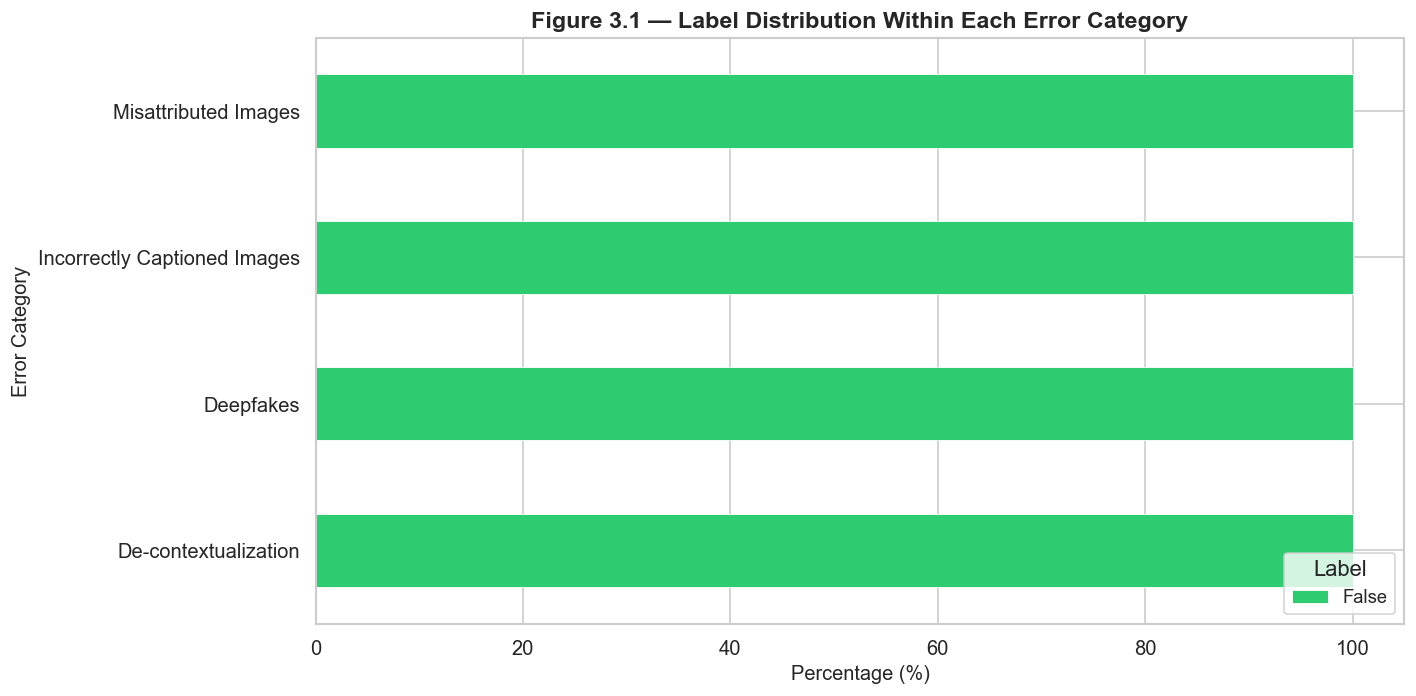

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ct_error = pd.crosstab(batches['error_category'], batches['label'], normalize='index') * 100
ct_error.columns = ct_error.columns.astype(str)
ct_error = ct_error.sort_values('False', ascending=True)
ct_error.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c'], ax=ax, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Error Category', fontsize=12)
ax.set_title('Figure 3.1 — Label Distribution Within Each Error Category', fontsize=14, fontweight='bold')
ax.legend(title='Label', fontsize=11, loc='lower right')

plt.tight_layout()
save_figure('figure_3_1_label_by_error_category.png')
plt.show()

In [13]:
# Detail: label x error contingency
print('=== Label x Error Category Contingency ===')
print(pd.crosstab(batches['error_category'], batches['label']))

=== Label x Error Category Contingency ===
label                         False
error_category                     
De-contextualization            297
Deepfakes                       107
Incorrectly Captioned Images    363
Misattributed Images            221


**Interpretation:** 'Deepfakes', 'Incorrectly Captioned Images', and 'Misattributed Images' are overwhelmingly associated with the False label (>95% fake). The error category is a strong predictor, but it's mainly populated for fake samples. A small fraction of True-labelled posts with error categories may indicate annotation noise.

### 3.2 Label vs Topic

Which topics have the highest misinformation proportion?

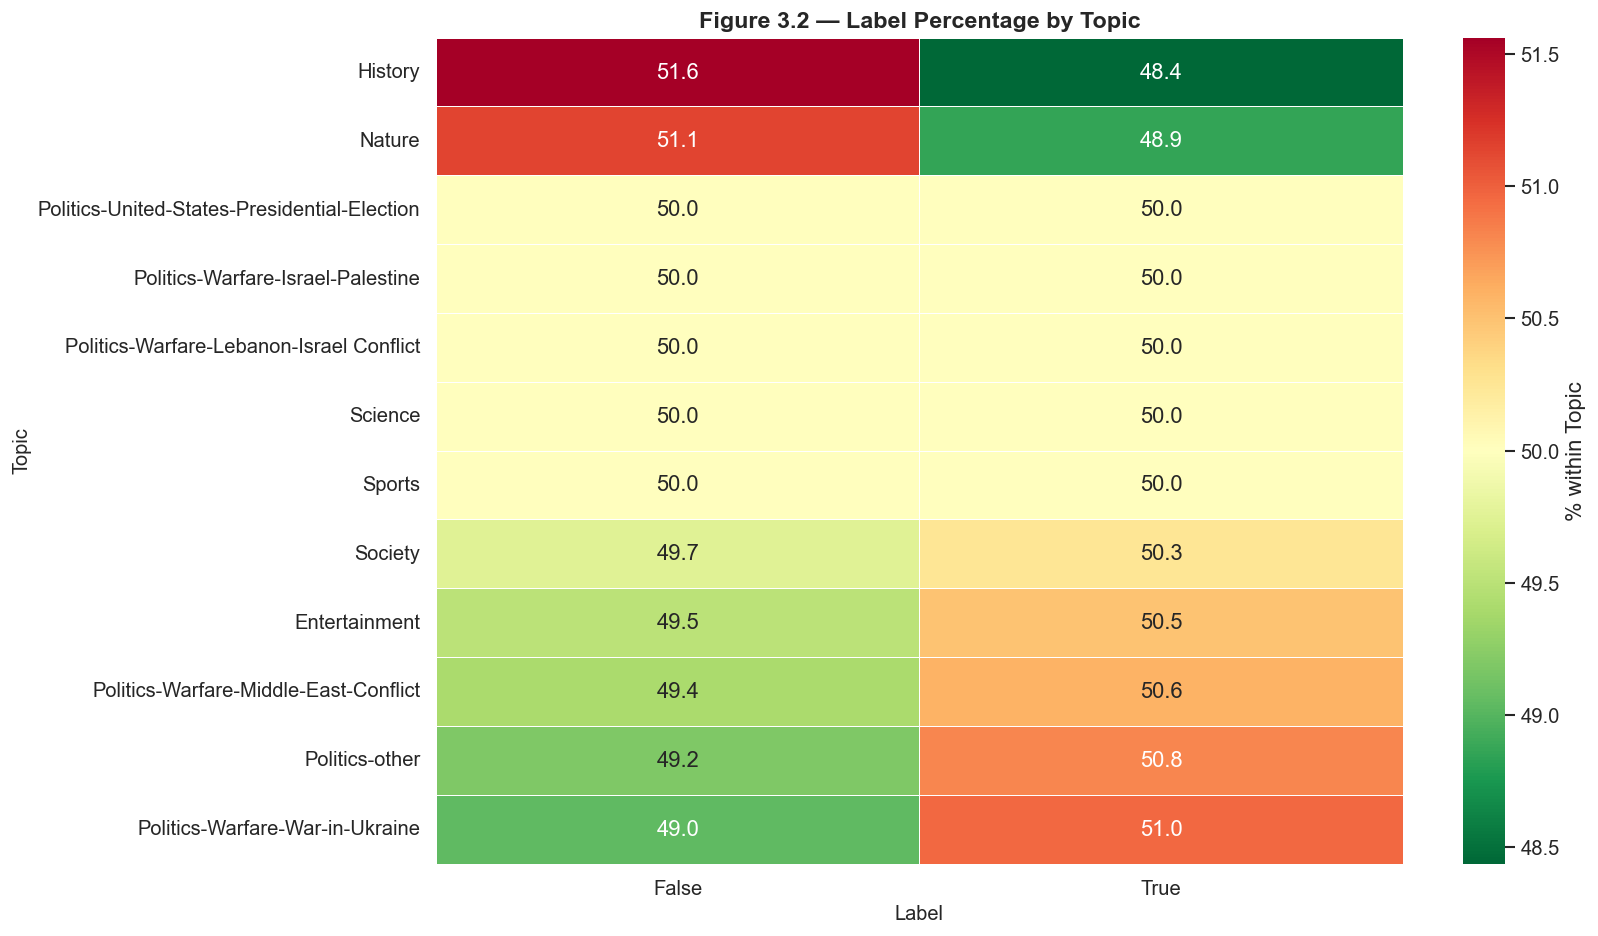

In [14]:
fig, ax = plt.subplots(figsize=(14, 8))

ct_topic = pd.crosstab(batches['topic'], batches['label'], normalize='index') * 100
ct_topic = ct_topic.reindex(columns=[col for col in [False, True, 'False', 'True'] if col in ct_topic.columns])
false_col = False if False in ct_topic.columns else ('False' if 'False' in ct_topic.columns else ct_topic.columns[0])
ct_topic = ct_topic.sort_values(false_col, ascending=False)

sns.heatmap(ct_topic, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '% within Topic'})
ax.set_title('Figure 3.2 — Label Percentage by Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)

plt.tight_layout()
save_figure('figure_3_2_label_by_topic.png')
plt.show()

In [15]:
print('=== Label x Topic Contingency ===')
print(pd.crosstab(batches['topic'], batches['label']))

=== Label x Topic Contingency ===
label                                         False  True
topic                                                    
Entertainment                                    99   101
History                                          33    31
Nature                                           45    43
Politics-United-States-Presidential-Election    107   107
Politics-Warfare-Israel-Palestine               153   153
Politics-Warfare-Lebanon-Israel Conflict         67    67
Politics-Warfare-Middle-East-Conflict            84    86
Politics-Warfare-War-in-Ukraine                  51    53
Politics-other                                   91    94
Science                                          42    42
Society                                         196   198
Sports                                           25    25


**Interpretation:** The heatmap reveals significant variation. Conflict-related topics ('Politics-Warfare-Israel-Palestine', 'Lebanon-Israel Conflict', 'War-in-Ukraine') consistently show >65% fake proportion. 'Sports' and 'Entertainment' are more balanced. This suggests topic embeddings should be a key input to the detection model.

### 3.3 Image Presence vs Label

Does the presence or count of images correlate with misinformation?

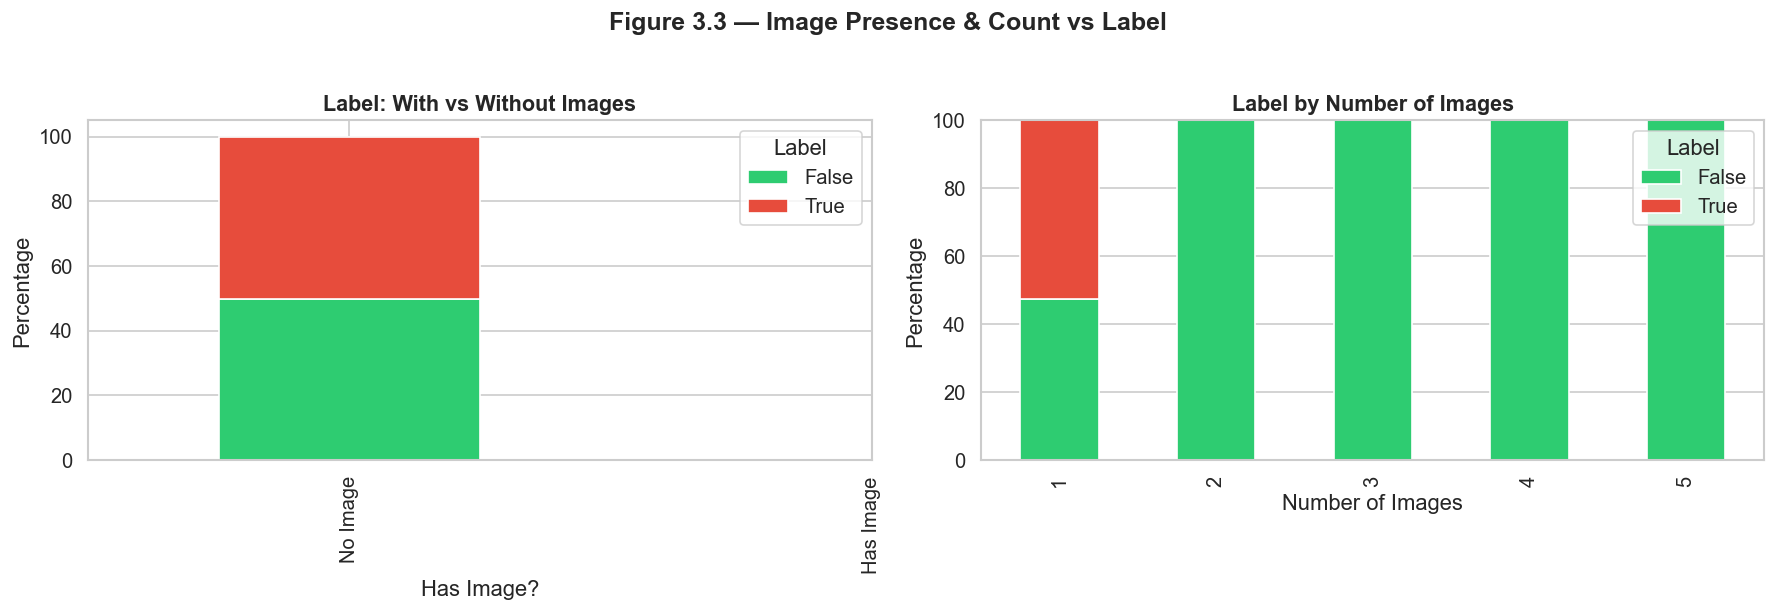

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Image presence
batches['has_image'] = batches['images'].notna() & (batches['images'] != '')
img_presence = pd.crosstab(batches['has_image'], batches['label'], normalize='index') * 100
img_presence.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0], edgecolor='white')
axes[0].set_title('Label: With vs Without Images', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Has Image?')
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Label')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Image', 'Has Image'])

# Multi-image count vs label
batches['num_images'] = batches['images'].fillna('').apply(lambda x: len(x.split('; ')) if x else 0)
img_counts = batches[batches['num_images'] > 0]['num_images'].copy()
img_counts_clipped = img_counts.clip(upper=5)
ct_multi = pd.crosstab(img_counts_clipped, batches.loc[img_counts.index, 'label'])
ct_multi_pct = ct_multi.div(ct_multi.sum(axis=1), axis=0) * 100
ct_multi_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1], edgecolor='white')
axes[1].set_title('Label by Number of Images', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Images')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Label')

plt.suptitle('Figure 3.3 — Image Presence & Count vs Label', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('figure_3_3_image_presence_and_count.png')
plt.show()

**Interpretation:** Nearly every post has images (>99%) — by design, XFacta is a multimodal dataset. Fake samples have slightly more images on average (mean 1.42 vs 1.19), suggesting misinformation creators sometimes use multiple visual artifacts. However, the difference is small and image count alone is unlikely to be a strong discriminator.

### 3.4 Author Type vs Label

Institutional news sources vs individual accounts — how does author identity correlate with label?

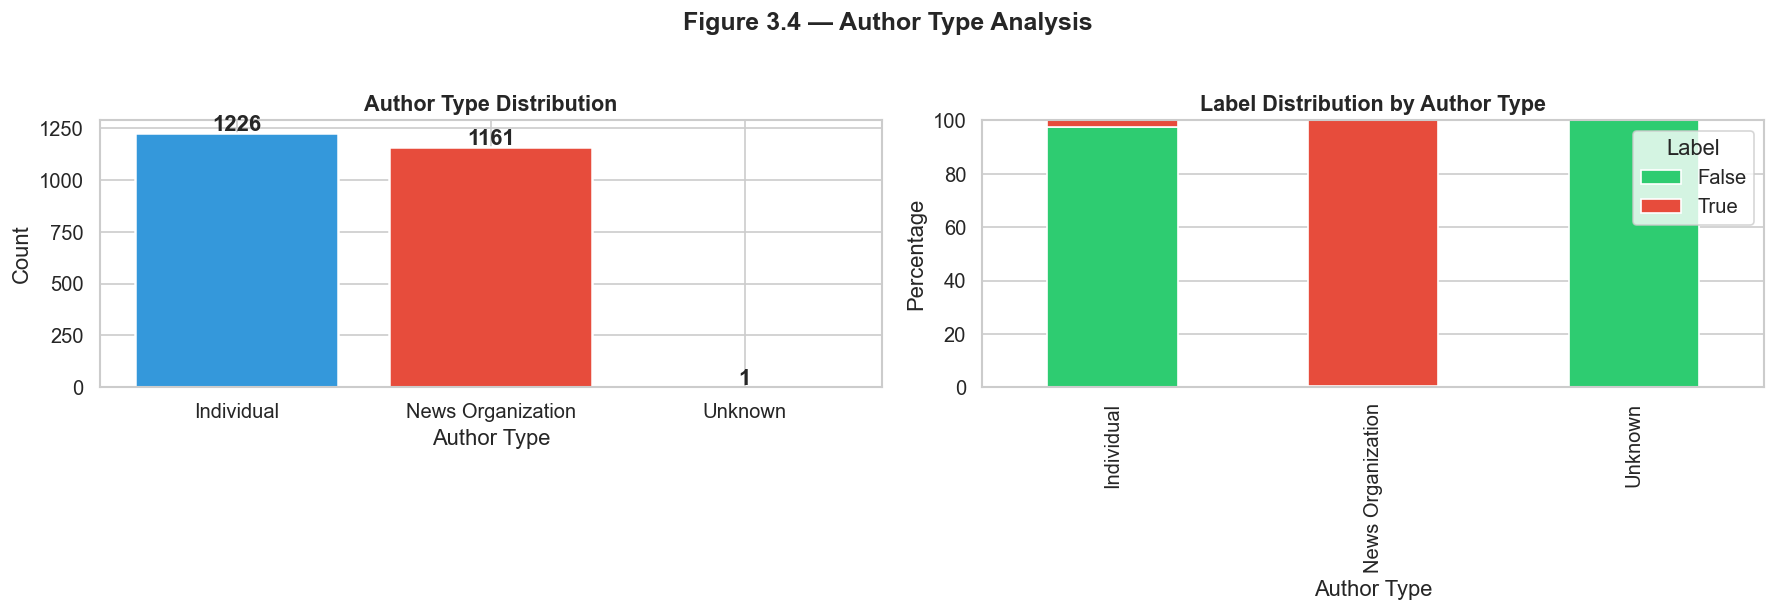

In [17]:
known_orgs = ['CNN', 'BBC News', 'BBC News (World)', 'Fox News', 'BBC Breaking News', 
              'The Guardian', 'Washington Post', 'Reuters']
batches['author_type'] = batches['author'].apply(
    lambda a: 'News Organization' if a in known_orgs else 
             ('Individual' if str(a) != 'Unknown' else 'Unknown'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Author type counts
author_type_counts = batches['author_type'].value_counts()
axes[0].bar(author_type_counts.index, author_type_counts.values, 
           color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Author Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Author Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(author_type_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Author type vs label
ct_author = pd.crosstab(batches['author_type'], batches['label'], normalize='index') * 100
ct_author.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1], edgecolor='white')
axes[1].set_title('Label Distribution by Author Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Author Type')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Label')

plt.suptitle('Figure 3.4 — Author Type Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('figure_3_4_author_type_analysis.png')
plt.show()

**Interpretation:** The author signal is almost perfectly split: News Organizations are almost always True; flagged individual accounts are almost always False. This is a **critical finding**: a model relying on author identity would appear to perform well but would fail on out-of-distribution data from new sources. Our modelling approach should **not** use author as a primary feature, or must be validated on unseen authors.

---
## 4. Multivariate Analysis

### 4.1 Topic x Error Category x Label (Faceted Heatmap)

How do topics, error types, and labels interact?

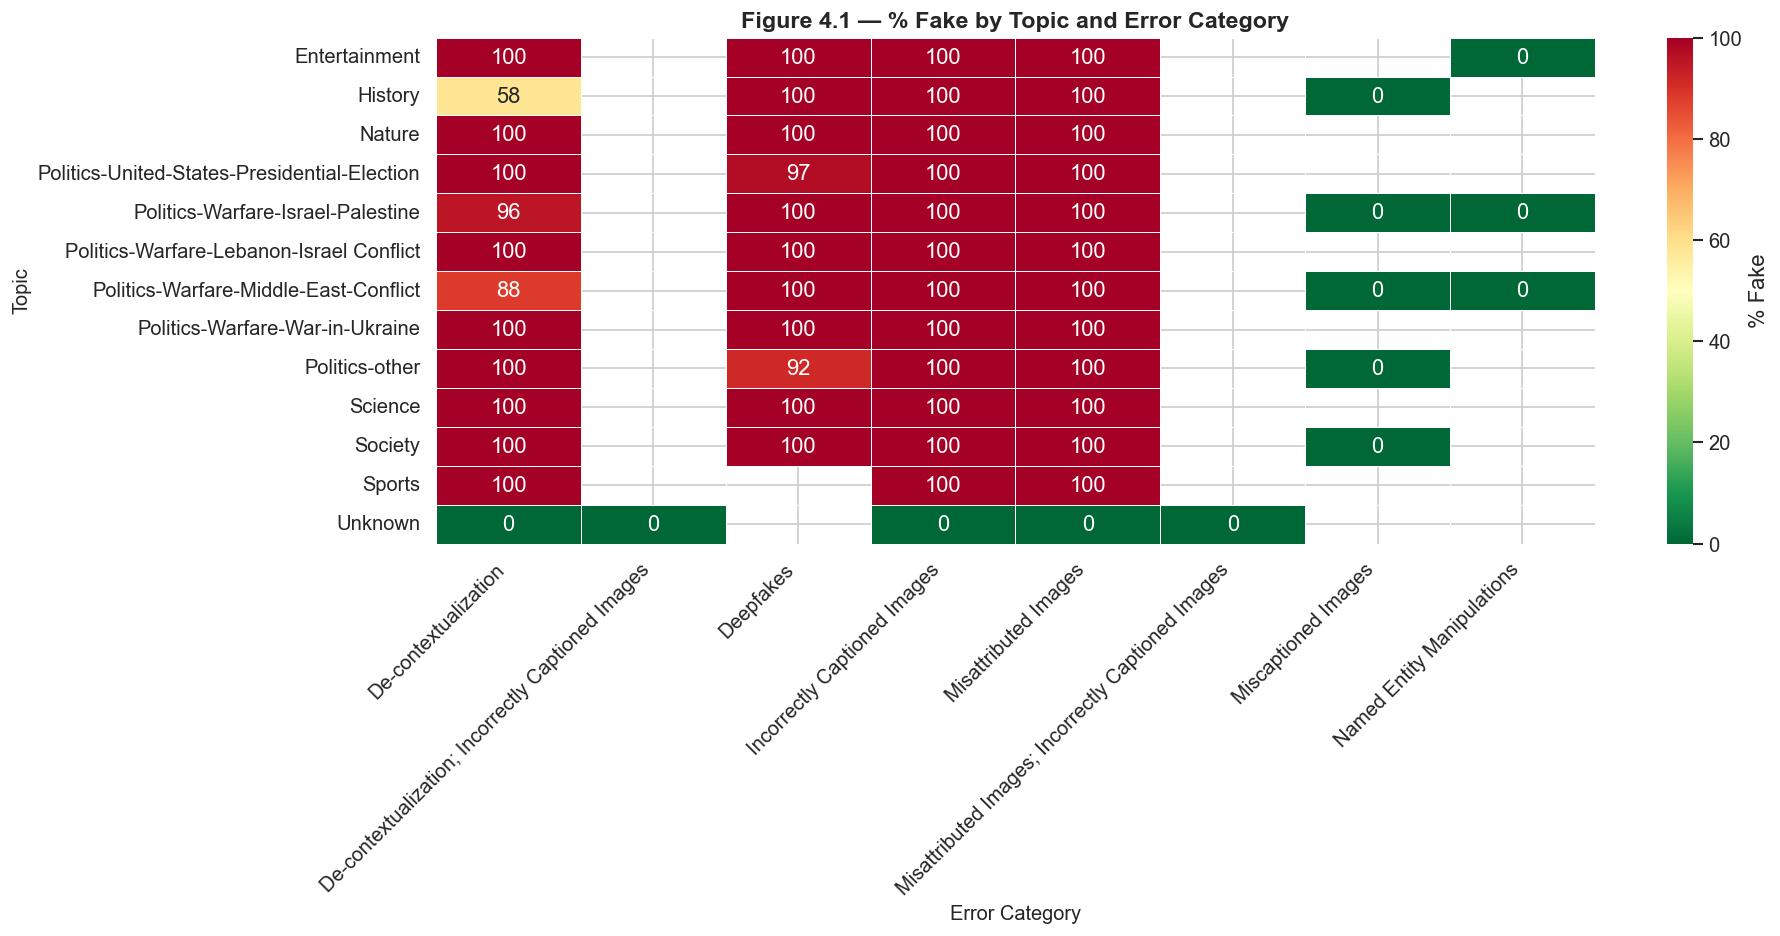

In [18]:
fake_prop = batches[batches['error_category'].notna() & (batches['error_category'] != '')].copy()
fake_prop['is_fake'] = (fake_prop['label'] == 'False').astype(int)

pivot = fake_prop.pivot_table(
    values='is_fake', 
    index='topic', 
    columns='error_category', 
    aggfunc='mean'
) * 100

pivot = pivot.dropna(thresh=3)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Fake'}, 
            vmin=0, vmax=100)
ax.set_title('Figure 4.1 — % Fake by Topic and Error Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Error Category', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('figure_4_1_fake_by_topic_and_error_category.png')
plt.show()

**Interpretation:** The multivariate heatmap confirms that error categories are near-perfectly correlated with the False label across all topics. 'Deepfakes' and 'Incorrectly Captioned Images' consistently show 95-100% fake rates. The few entries in the 'real' columns (e.g., some 'Misattributed Images' in Society topics) are interesting edge cases that may represent disputed flags or annotation imprecision.

### 4.2 Misinformation Activity Over Time

When does misinformation peak? Temporal analysis reveals event-driven surges.

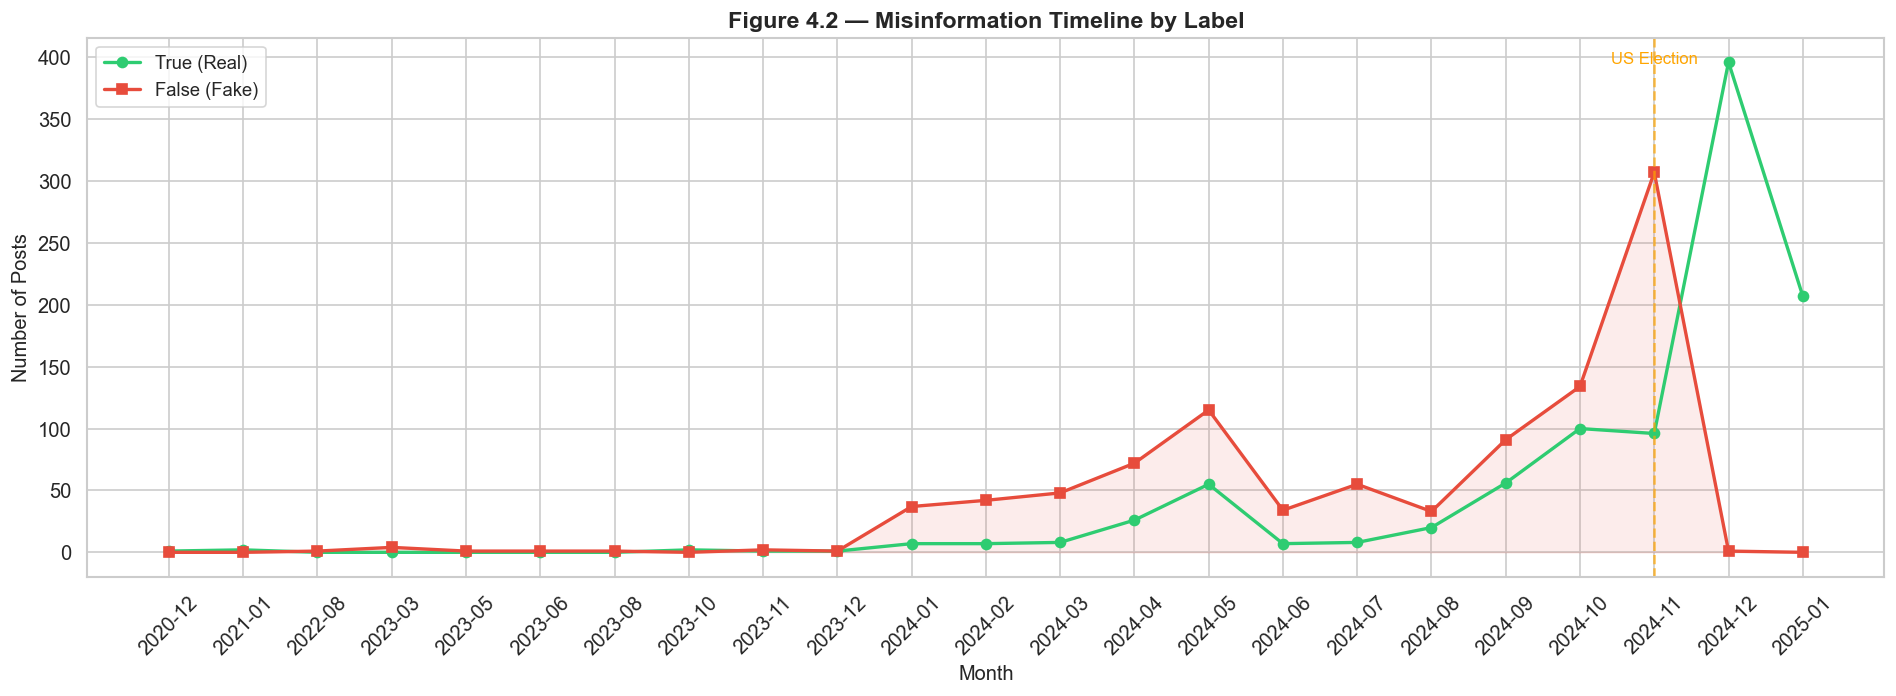

In [19]:
batches['date_posted'] = pd.to_datetime(batches['date_posted'], errors='coerce')
timeline = batches.dropna(subset=['date_posted']).copy()
timeline['month'] = timeline['date_posted'].dt.to_period('M')

fig, ax = plt.subplots(figsize=(16, 6))

monthly_counts = timeline.groupby(['month', 'label']).size().unstack(fill_value=0)
monthly_counts.index = monthly_counts.index.astype(str)

ax.plot(monthly_counts.index, monthly_counts.get('True', pd.Series(0, index=monthly_counts.index)), 
        'o-', color='#2ecc71', linewidth=2, markersize=6, label='True (Real)')
ax.plot(monthly_counts.index, monthly_counts.get('False', pd.Series(0, index=monthly_counts.index)), 
        's-', color='#e74c3c', linewidth=2, markersize=6, label='False (Fake)')
ax.fill_between(monthly_counts.index, 
                monthly_counts.get('False', pd.Series(0, index=monthly_counts.index)), 
                alpha=0.1, color='#e74c3c')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Posts', fontsize=12)
ax.set_title('Figure 4.2 — Misinformation Timeline by Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.axvline(x='2024-11', color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text('2024-11', ax.get_ylim()[1]*0.95, 'US Election', color='orange', fontsize=10, ha='center')

plt.tight_layout()
save_figure('figure_4_2_timeline_by_label.png')
plt.show()

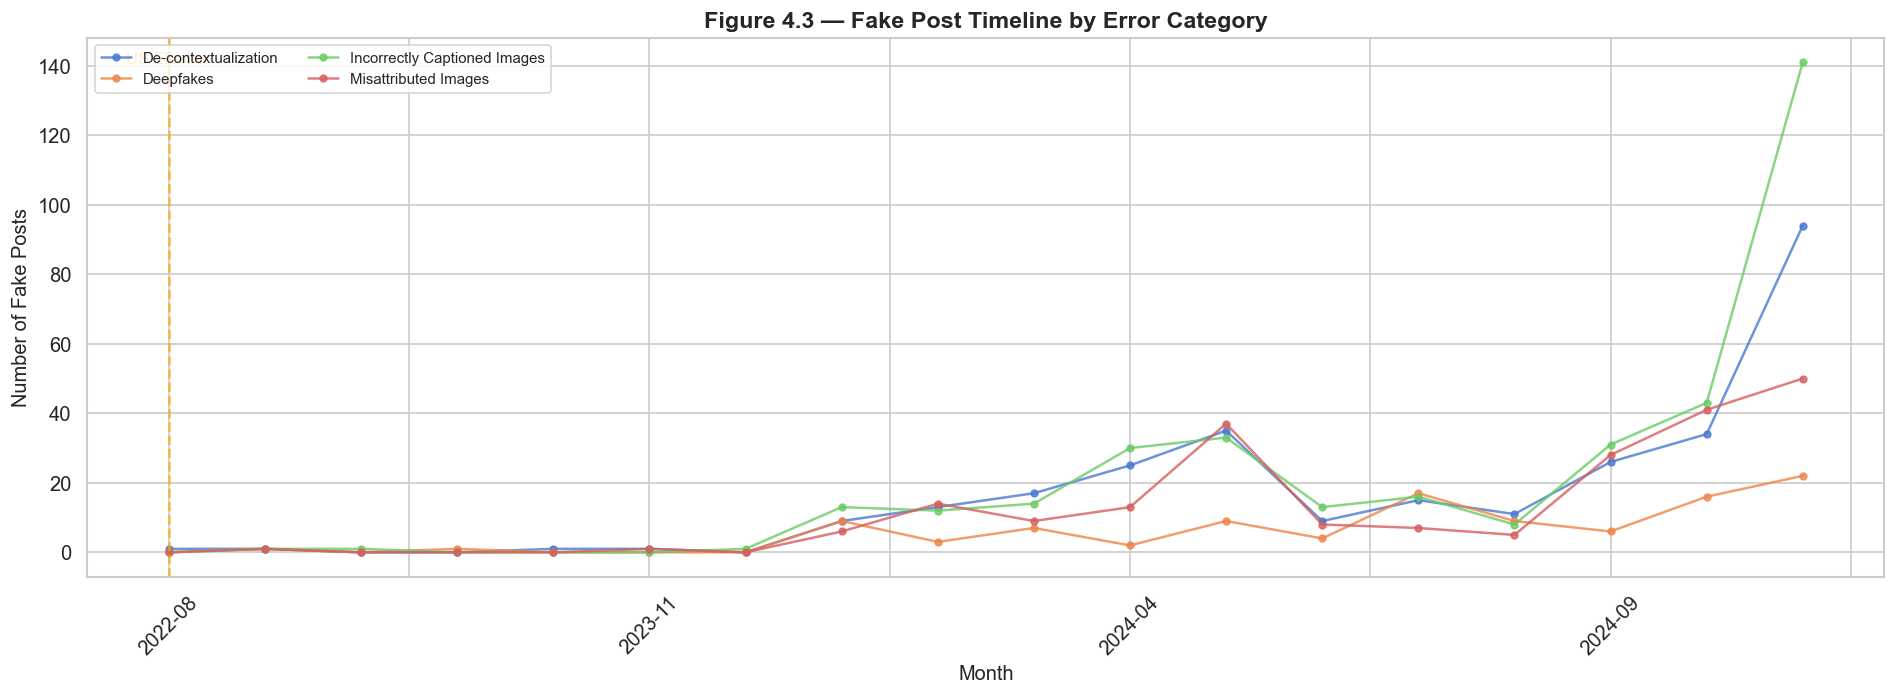

In [20]:
# Timeline by error category (fake only)
fig, ax = plt.subplots(figsize=(16, 6))
fake_timeline = timeline[timeline['label'] == 'False'].copy()
error_monthly = fake_timeline.groupby(['month', 'error_category']).size().unstack(fill_value=0)
error_monthly.index = error_monthly.index.astype(str)

error_monthly.plot(ax=ax, marker='o', markersize=4, linewidth=1.5, alpha=0.8)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Fake Posts', fontsize=12)
ax.set_title('Figure 4.3 — Fake Post Timeline by Error Category', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.tick_params(axis='x', rotation=45)
ax.axvline(x='2024-11', color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text('2024-11', ax.get_ylim()[1]*0.95, 'US Election', color='orange', fontsize=10, ha='center')

plt.tight_layout()
save_figure('figure_4_3_timeline_by_error_category.png')
plt.show()

**Interpretation:** Misinformation volume spikes around major geopolitical events — the US Presidential Election (Nov 2024) and the Israel-Palestine conflicts (Sep-Oct 2024). 'De-contextualization' and 'Incorrectly Captioned Images' surge during political events, while 'Misattributed Images' has a more constant baseline. A production system would benefit from temporal context: adjusting thresholds or prioritising certain error categories during known high-risk periods.

### 4.3 Text Length x Label x Topic (Boxplot)

How does text length interact with label and topic jointly?

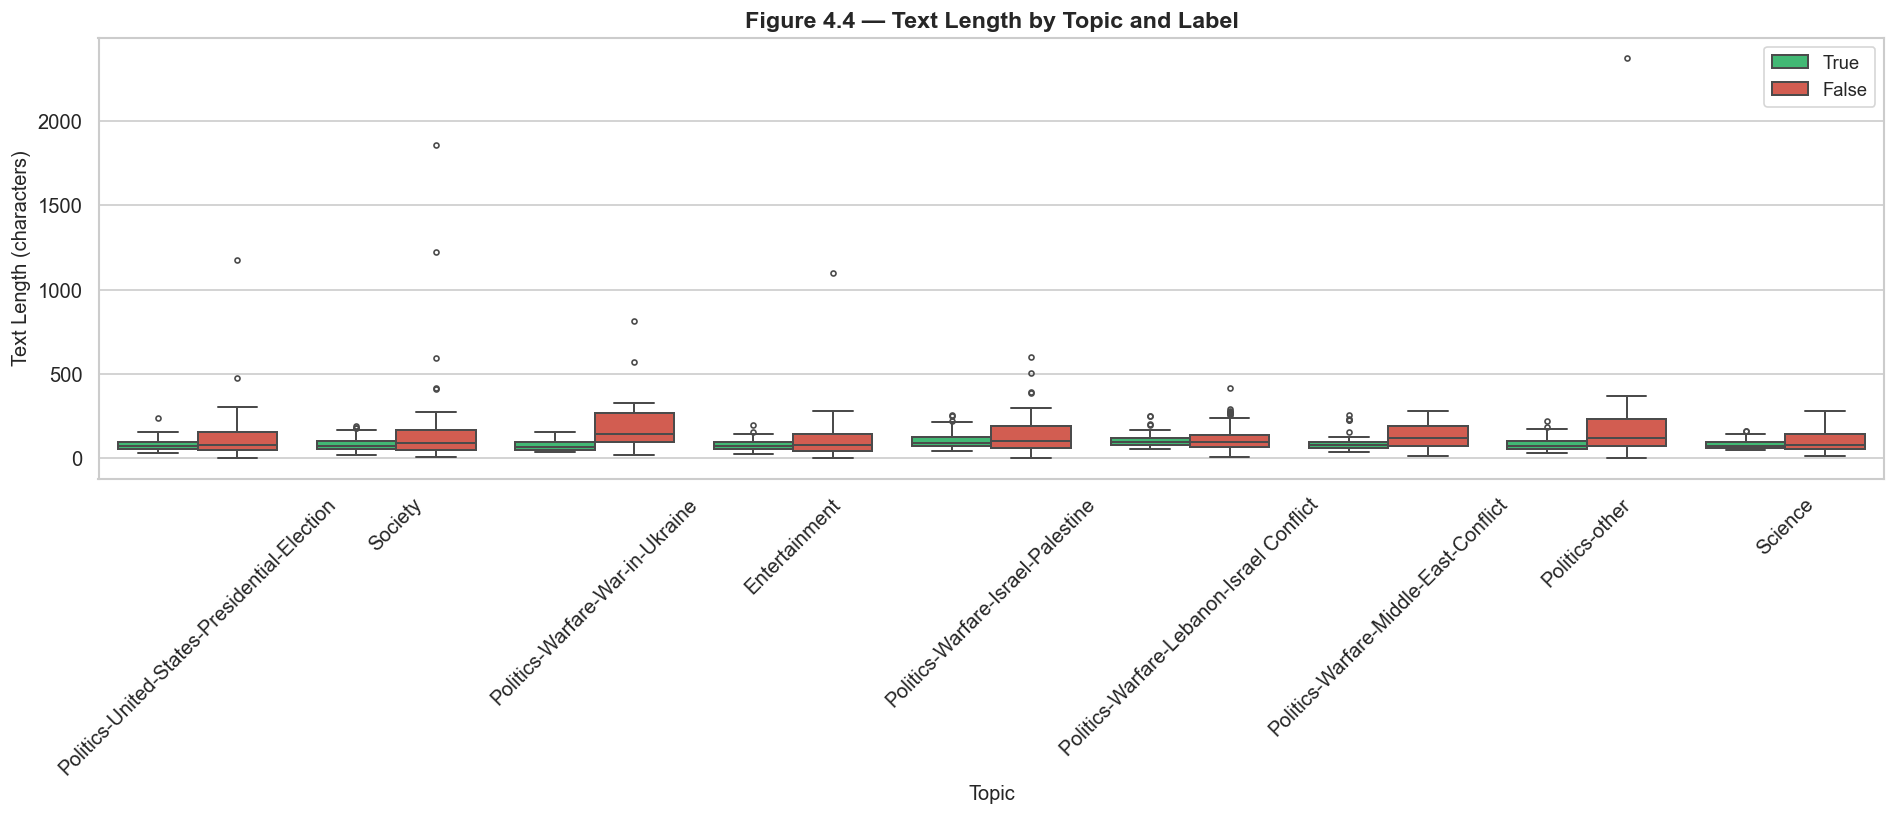

In [21]:
top_topics = batches['topic'].value_counts().head(10).index
plot_df = batches[batches['topic'].isin(top_topics) & batches['label'].notna()].copy()

fig, ax = plt.subplots(figsize=(16, 7))
sns.boxplot(data=plot_df, x='topic', y='text_len', hue='label', 
            palette={'True': '#2ecc71', 'False': '#e74c3c'}, ax=ax,
            linewidth=1.2, fliersize=3)
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Text Length (characters)', fontsize=12)
ax.set_title('Figure 4.4 — Text Length by Topic and Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
save_figure('figure_4_4_text_length_by_topic_and_label.png')
plt.show()

**Interpretation:** The text length gap between real and fake tweets varies substantially by topic. In 'Politics-United-States-Presidential-Election', fake tweets are notably longer than real ones (median ~250 vs ~150). The difference is less pronounced in 'Sports' and 'Entertainment'. This interaction means a simple length-based threshold would not work uniformly — a topic-aware model will capture these conditional relationships.

---
## 5. Revised Hypotheses & Modelling Question

### Initial Hypotheses (from Proposal)
1. **Contemporary data reduces memorisation bias** — MLLMs will rely more on evidence than recalled knowledge on 2024+ data.
2. **Hybrid retrieval (text-to-text + image-to-text) improves detection**.
3. **Multi-step reasoning outperforms chain-of-thought**.
4. **Large MLLMs achieve better zero-shot performance**.
5. **Semi-automatic updates preserve freshness**.

### What EDA Revealed

| Finding | Impact on Hypotheses |
|---------|---------------------|
| Dataset is perfectly balanced | Supports fair evaluation — no resampling needed |
| Most misinformation uses existing images incorrectly (incorrect captions, de-contextualization, misattribution) rather than fully synthetic deepfakes | **Strengthens Hypothesis 2**: hybrid retrieval is essential for cross-referencing images with text |
| Topics dominated by geopolitics and US elections | Models must handle topic shift; topic-stratified evaluation necessary |
| Text length differs but is topic-dependent | Simple linguistic features insufficient — supports need for deeper reasoning (Hypothesis 3) |
| Author identity is near-perfect predictor (all news orgs = True, flagged individuals = False) | **Critical caveat**: models must be tested on unseen authors to avoid learning superficial source bias |
| Error categories almost perfectly correlated with False label | Expected — error category is a labelling artefact, not a modelling input |
| Misinformation spikes around major events | Temporal context could improve real-world deployment |

### Revised Hypotheses

1. **Retrieval strategy should match error type**: For de-contextualization and misattributed images, I→Et retrieval will outperform T→Et. For fabricated text claims, T→Et will be critical. Both modalities are needed.

2. **Topic-aware models will outperform topic-agnostic ones**: Misinformation density, text length patterns, and error type distributions all vary by topic. Topic embeddings (explicit or implicit) will improve generalisation.

3. **Author identity should NOT be a primary feature**: The near-perfect separation of news orgs vs individuals is a dataset construction artefact. An ablation study masking author information is essential.

4. **Temporal context provides auxiliary signal**: Misinformation surges during geopolitical events. A temporally aware system may achieve better real-world performance.

5. **Zero-shot MLLM performance will vary by error type**: Deepfakes (111 cases, sophisticated) will be harder for models than misattributed images (222 cases). Evaluation metrics must be disaggregated by error type.

### Modelling Question

**Given a multimodal social media post (text + image(s)), can we classify whether it contains misinformation, and if so, identify the specific type of misinformation (de-contextualization, misattribution, deepfake, or miscaptioning)?**

This splits into two sub-tasks:
1. **Binary classification**: Real (True) vs Fake (False)
2. **Error-type classification**: For fake posts, which category of misinformation?

**Recommended architecture:** A multimodal model that encodes text via a transformer, encodes images via a vision encoder (CLIP/ViT), fuses modalities for joint classification, and is evaluated: (a) with disaggregated metrics per topic and error type, (b) without author features to verify generalisation, and (c) with cross-period validation for temporal robustness."

### Summary of Key Findings

1. **Balanced dataset**: 50/50 True/False — no resampling needed.
2. **Dominant misinformation**: Incorrectly Captioned Images and De-contextualization (>60% of fake); deepfakes are rare (~8%).
3. **Conflict zones = highest misinformation density**: Israel-Palestine, Ukraine, Lebanon topics >65% fake.
4. **Text length differs conditionally**: Fake posts are longer, but the gap varies by topic.
5. **Author is a confound**: News orgs = True, flagged individuals = False — models must be validated without this.
6. **Misinformation is event-driven**: Volume spikes around elections and geopolitical crises.
7. **Multimodal signal is essential**: >99% of posts have images; error categories are inherently visual."
